In [1]:

import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
# from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt

import math
import plotly.express as px

In [2]:
df = pd.read_csv("../data/papers.csv")
total_papers = len(df)
df.columns

Index(['Title', 'Database', 'Year', 'Month', 'Journal', 'Paper Type',
       'Data Source', 'Data Country', 'Data Domain', 'Data Language',
       'Data Availability', 'Link to Data', 'Data Details', 'Size',
       'Number of Prompts', 'Medical Application', 'Task Type', 'Topic',
       'Note', 'Bias Evaluation Metric', 'Bias Definition', 'Conclusions',
       'Race / Ethnic Bias', 'Language Bias', 'Age Bias', 'Gender Bias',
       'Other Bias', 'LGBTQ+ Bias', 'Disability Bias',
       'Geography / Cultural Bias', 'Evaluated LLMs',
       'Reference Standard \n(Human / Model / System / Physician)',
       'Patient Inclusion\n(Yes / No)', 'Has Debiasing',
       'Debias - Focus\n(Data/Train/Inference)', 'Debias-details'],
      dtype='str')

In [3]:
data_lang_lst = df["Data Language"].tolist()

data_lang_freqs = defaultdict(int)

for a in data_lang_lst:  

    if isinstance(a, float):
        data_lang_freqs[str(a)] += 1
        continue

    s = a.strip().lower()
    
    languages = [l.strip() for l in s.split(',')]
    
    for lang in languages:
        data_lang_freqs[lang] += 1



In [5]:
data_lang_freqs["english"] += 1
del data_lang_freqs["engllish"]

data_lang_freqs["chinese"] += 2
del data_lang_freqs["traditional chinese"]
del data_lang_freqs["simplified chinese"]

del data_lang_freqs["nan"]


data_lang_freqs

defaultdict(int,
            {'english': 48,
             'chinese': 4,
             'arabic': 3,
             'spanish': 1,
             'french': 1,
             'polish': 1})

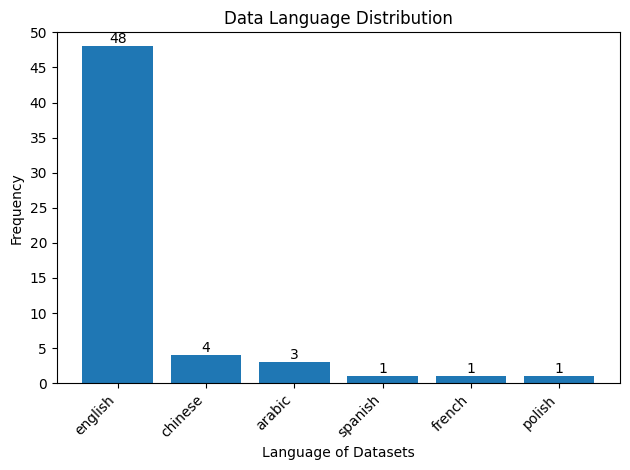

In [8]:
plt.figure()

languages = list(data_lang_freqs.keys())
counts = list(data_lang_freqs.values())

bars = plt.bar(languages, counts)

for i, count in enumerate(counts):
    # percent = (count / total_papers) * 100
    plt.text(i, count, f"{count}",
             ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Language of Datasets")
plt.ylabel("Frequency")
plt.ylim((0, 50))
plt.yticks(range(0, 51, 5))
plt.title("Data Language Distribution")
plt.tight_layout()
plt.show()